In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration pour la visualisation
%matplotlib inline
sns.set_theme(style="whitegrid")

## Importation & Exploration

In [27]:
df = pd.read_csv('bank-transactions.csv')

print("--- Structure inspection ---")
display(df.shape)

print("--- types ---")
display(df.dtypes)

print("--- head ---")
display(df.head())

print("--- describe ---")
display(df.describe())

--- Structure inspection ---


(2060, 16)

--- types ---


transaction_id          object
client_id               object
date_transaction        object
montant                 object
devise                  object
taux_change_eur        float64
montant_eur            float64
categorie               object
produit                 object
agence                  object
type_operation          object
statut                  object
score_credit_client    float64
segment_client          object
solde_avant             object
taux_interet           float64
dtype: object

--- head ---


,transaction_id,client_id,date_transaction,montant,devise,taux_change_eur,montant_eur,categorie,produit,agence,type_operation,statut,score_credit_client,segment_client,solde_avant,taux_interet
0,TXN000559,CLI0060,2022-04-19 02:31:00,2050.42,EUR,1.00,2050.42,Depot especes,Compte Epargne,Marseille-Vieux-Port,Credit,Complete,NaN,Premium,16415.1,NaN
1,TXN001154,CLI0057,2024-06-20 20:51:00,-123.66,GBP,0.86,-143.79,Retrait DAB,Credit Consommation,NaN,Debit,Rejete,435.0,Risque,42890.81,NaN
2,TXN000764,CLI0015,2024-08-28 05:03:00,-396.17,EUR,1.00,-396.17,Prelevement,PEA,Lyon-Part-Dieu,Debit,Complete,648.0,Standard,48489.38,NaN
3,TXN001598,CLI0045,2024-01-07 08:16:00,225.2,EUR,1.00,225.20,Paiement CB,Credit Consommation,Bordeaux-Meriadeck,Credit,Complete,704.0,Standard,43962.51,NaN
4,TXN001873,CLI0034,2024-08-11 19:52:00,935.32,EUR,1.00,935.32,Interets,Credit Immobilier,Bordeaux-Meriadeck,Credit,Complete,457.0,Risque,17312.83,NaN


--- describe ---


,taux_change_eur,montant_eur,score_credit_client,taux_interet
count,2060.000000,2060.000000,1893.000000,0.0
mean,1.534782,-116.223170,627.866350,NaN
std,2.234708,2083.777234,132.193879,NaN
min,0.860000,-8705.810000,-100.000000,NaN
25%,1.000000,-1218.870000,586.000000,NaN
50%,1.000000,-60.405000,643.000000,NaN
75%,1.000000,957.805000,701.000000,NaN
max,10.850000,9026.940000,1500.000000,NaN


In [28]:
print("--- missing values percentage ---")
df.isna().mean() * 100

--- missing values percentage ---


transaction_id           0.000000
client_id                0.000000
date_transaction         0.000000
montant                  0.000000
devise                   0.000000
taux_change_eur          0.000000
montant_eur              0.000000
categorie                0.000000
produit                  0.000000
agence                   3.106796
type_operation           0.000000
statut                   0.000000
score_credit_client      8.106796
segment_client           5.097087
solde_avant              0.000000
taux_interet           100.000000
dtype: float64

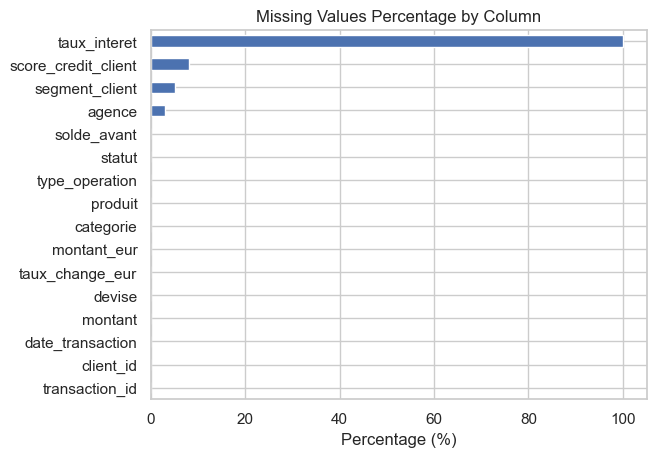

In [29]:
missing = df.isna().mean() * 100
missing.sort_values().plot(kind="barh")
plt.title("Missing Values Percentage by Column")
plt.xlabel("Percentage (%)")
plt.show()

In [30]:
df.duplicated(subset="transaction_id").sum()

np.int64(60)

In [31]:
duplicates = df[df.duplicated(subset="transaction_id", keep=False)]
display(duplicates.sort_values("transaction_id").head(10))

,transaction_id,client_id,date_transaction,montant,devise,taux_change_eur,montant_eur,categorie,produit,agence,type_operation,statut,score_credit_client,segment_client,solde_avant,taux_interet
750,TXN000034,CLI0099,2024-02-21 18:22:00,0.0,EUR,1.00,1745.70,Interets,Assurance Vie,Nantes-Commerce,Credit,Complete,664.0,Standard,41518.87,NaN
1379,TXN000034,CLI0099,2024-02-21 18:22:03,1745.7,EUR,1.00,1745.70,Interets,Assurance Vie,Nantes-Commerce,Credit,Complete,664.0,Standard,41518.87,NaN
1128,TXN000052,CLI0076,31/05/2024 03:50,2120.25,EUR,1.00,2120.25,Interets,Credit Consommation,Lyon-Part-Dieu,Credit,Complete,326.0,Risque,44415.74,NaN
394,TXN000052,CLI0076,2024-05-31 03:50:03,2120.25,EUR,1.00,2120.25,Interets,Credit Consommation,Lyon-Part-Dieu,Credit,Complete,326.0,Risque,44415.74,NaN
14,TXN000116,CLI0077,2024-11-09 17:31:03,-5728.17,EUR,1.00,-5728.17,Virement international,Compte Courant,Paris-Centre,Debit,Complete,322.0,Risque,33722.94,NaN
112,TXN000116,CLI0077,2024-11-09 17:31:00,-5728.17,EUR,1.00,-5728.17,Virement international,Compte Courant,Paris-Centre,Debit,Complete,322.0,Risque,33722.94,NaN
1308,TXN000121,CLI0064,06/04/2023 09:49,-158.72,EUR,1.00,-158.72,Paiement CB,Credit Auto,Lille-Grand-Place,Debit,Complete,NaN,Premium,17505.28,NaN
1615,TXN000121,CLI0064,2023-04-06 09:49:00,-158.72,EUR,1.00,-158.72,Paiement CB,Credit Auto,Lille-Grand-Place,Debit,Complete,NaN,Premium,17505.28,NaN
594,TXN000127,CLI0046,2024-03-24 15:11:00,2813.0,MAD,10.85,259.26,Virement,Assurance Vie,NaN,Credit,Complete,NaN,Premium,562.43,NaN
164,TXN000127,CLI0046,2024-03-24 15:11:03,2813.0,MAD,10.85,259.26,Virement,Assurance Vie,NaN,Credit,Complete,NaN,Premium,562.43,NaN


## Nettoyage des données

Supprimer les doublons : conserver la première occurrence par transaction_id

In [32]:
df = df.drop_duplicates(subset=["transaction_id"], keep="first")

df.duplicated(subset="transaction_id").sum()

np.int64(0)

Corriger les types de dates : unifier au format AAAA-MM-JJ HH:MM:SS

In [33]:
df['date_transaction'] = pd.to_datetime(df['date_transaction'], format='mixed', dayfirst=True, errors='coerce')

In [34]:
df['date_transaction'] = df['date_transaction'].dt.strftime('%Y-%m-%d %H:%M:%S')

In [35]:
df['date_transaction'].isna().sum()

np.int64(0)

In [36]:
df['date_transaction'].head(10)

0    2022-04-19 02:31:00
1    2024-06-20 20:51:00
2    2024-08-28 05:03:00
3    2024-01-07 08:16:00
4    2024-08-11 19:52:00
5    2024-04-28 23:08:00
6    2023-09-13 12:04:00
7    2022-05-11 08:57:00
8    2022-10-24 11:30:00
9    2022-04-21 21:15:00
Name: date_transaction, dtype: object

Corriger les montants : remplacer les virgules par des points, convertir en float

In [37]:
if df['montant'].dtype == 'object':
    df['montant'] = df['montant'].str.replace(',', '.').astype(float)

In [38]:
df['montant'].isna().sum()

np.int64(0)

In [39]:
df['montant'].dtype

dtype('float64')

Nettoyer la colonne solde_avant : supprimer le suffixe texte ' EUR', convertir en float

In [40]:
# D. Nettoyer solde_avant (supprimer ' EUR')
df['solde_avant'] = (df['solde_avant'].astype(str).str.replace(' EUR', '', regex=False).str.replace(',', '.').astype(float))


In [41]:
df['solde_avant'].astype(str).str.contains('EUR').sum()

np.int64(0)

In [42]:
df['solde_avant'].dtype

dtype('float64')

In [43]:
df['solde_avant'].isna().sum()

np.int64(0)

Normaliser les devises : passer en majuscules (eur → EUR)

In [44]:
df['devise'] = df['devise'].str.upper().str.strip()
df['devise'].unique()

array(['EUR', 'GBP', 'CHF', 'USD', 'MAD'], dtype=object)

Harmoniser segment_client : unifier la casse (PREMIUM → Premium)

In [45]:
df['segment_client'] = df['segment_client'].str.strip().str.capitalize()
df['segment_client'].unique()

array(['Premium', 'Risque', 'Standard', nan], dtype=object)

Supprimer les espaces parasites sur la colonne agence

In [46]:
df['agence'] = df['agence'].str.strip()

In [47]:

df['agence'].unique()

array(['Marseille-Vieux-Port', nan, 'Lyon-Part-Dieu',
       'Bordeaux-Meriadeck', 'Lille-Grand-Place', 'Toulouse-Capitole',
       'Nice-Massena', 'Paris-Centre', 'Nantes-Commerce'], dtype=object)

Traiter les valeurs manquantes : imputation par médiane, mode .....

In [48]:


# G. Supprimer les espaces parasites sur agence
df['agence'] = df['agence'].str.strip()

# H. Traiter les valeurs manquantes
# Imputation par médiane pour le numérique, mode pour le textuel
df['score_credit_client'] = df['score_credit_client'].fillna(df['score_credit_client'].median())
df['agence'] = df['agence'].fillna("Inconnue")
df['segment_client'] = df['segment_client'].fillna(df['segment_client'].mode()[0])

print("Nettoyage terminé. Valeurs manquantes restantes :", df.isnull().sum().sum())

Nettoyage terminé. Valeurs manquantes restantes : 2000


## Détection & Traitement des Valeurs Aberrantes

In [49]:
# A. Méthode IQR pour 'montant'
Q1_m = df['montant'].quantile(0.25)
Q3_m = df['montant'].quantile(0.75)
IQR_m = Q3_m - Q1_m
lower_m = Q1_m - 1.5 * IQR_m
upper_m = Q3_m + 1.5 * IQR_m

# B. Scores crédit (Bornes métier : 0 à 850)
# C. Créer la colonne is_anomaly
df['is_anomaly'] = (
    (df['montant'] < lower_m) | (df['montant'] > upper_m) |
    (df['score_credit_client'] < 0) | (df['score_credit_client'] > 850) |
    (df['montant'] == 0)
)

print(f"Nombre d'anomalies détectées : {df['is_anomaly'].sum()}")

# D. Documentation : Choix de conservation avec flag (pour audit bancaire)

Nombre d'anomalies détectées : 122


## Feature Engineering

In [50]:
# A. Extraire les composants de la date
df['annee'] = df['date_transaction'].dt.year
df['mois'] = df['date_transaction'].dt.month
df['trimestre'] = df['date_transaction'].dt.quarter
df['jour_semaine'] = df['date_transaction'].dt.day_name()

# B. Calculer montant_eur_verifie
df['montant_eur_verifie'] = df['montant'] / df['taux_change_eur']

# C. Créer categorie_risque
def risk_mapping(score):
    if score >= 700: return 'Low'
    elif 580 <= score <= 699: return 'Medium'
    else: return 'High'

df['categorie_risque'] = df['score_credit_client'].apply(risk_mapping)

# D. Agréger par client (Solde net, nb transactions, etc.)
client_metrics = df.groupby('client_id').agg(
    nb_transactions=('transaction_id', 'count'),
    montant_moyen=('montant', 'mean'),
    nb_produits_distincts=('produit', 'nunique')
).reset_index()

# Fusion avec le dataset principal pour enrichir
df = df.merge(client_metrics, on='client_id', how='left')

# E. Taux de rejet par agence
rejet_agence = df[df['statut'] == 'Rejete'].groupby('agence').size() / df.groupby('agence').size()
df['taux_rejet_agence'] = df['agence'].map(rejet_agence).fillna(0)

AttributeError: Can only use .dt accessor with datetimelike values